In [ ]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.44
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                 

In [ ]:
!nvidia-smi

Thu Apr 23 09:24:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   48C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")

PyTorch: 2.10.0+cu128
CUDA available: True
cuDNN version: 91002


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd drive/"MyDrive"/"Colab Notebooks"/"new_offRL"/"rl_v2_4"

/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_4


# ReBRAC screening: training budget probe

**目的**：为正式 screening 的 `TRAIN_EPOCHS` 选一个有据可依的值，而不是继续沿用 TD3BC 时代沿用下来但没单独调过的 64。

**方法**：不做 `TRAIN_EPOCHS ∈ {32, 64, 96, 128}` 的笛卡尔 sweep（浪费）。
利用 Stage B 协议已经对齐的 `CHECKPOINT_EVERY_EPOCHS=8` + 每个 ckpt 都走 val 的特性，
**把一个 cell 训长一次（128 epoch），读中间 ckpt 的 val 曲线**——16 个 val 点免费拿到。

等价前提：当前 `scripts/train_offline.py` 用常数 LR AdamW，
`sampling_mode=shuffle_no_replacement` 每个 epoch 独立 shuffle，
因此「长训至 step N」在优化动力学上≈「只训到 N 结束」。最后有一段 sanity check 可做交叉确认。

**实验 scope**：

| 轴 | 配置 | 说明 |
|---|---|---|
| β1 / β2 | `2.0 / 1.0` | 对齐 TD3BC α=0.25 的 phase0c 1000 winner，覆盖中等 BC 强度 |
| dataset | `crosscomp-1000` + `crosscomp-2000` | 本次核心假设：2000 是否需要比 1000 更大预算 |
| seeds | `42 43 44` | 同正式 screening，不浪费 |
| TRAIN_EPOCHS | `128` | 产出 16 个 ckpt（每 8 epoch 一个）|
| manifest | val=40 / test=40 | 与 Stage B 协议一致 |

**预算**：2 dataset × 1 cell × 3 seed = 6 个 run，约正式 screening（3×2×3×2=36 run / epoch=64）的 `1/6 × 128/64 ≈ 1/3`。

**输出树**：刻意与正式 screening 隔离：
- `checkpoints/offline/rebrac/screening_epoch_probe/`
- `results/offline/rebrac/screening_epoch_probe/`


## 0. 环境配置


In [5]:
import os

# —— 通用（与其它 ReBRAC / TD3BC 实验一致）——
os.environ["PYTHON_BIN"]         = "python3"
os.environ["DEVICE"]             = "cuda"
os.environ["EVAL_WORKERS"]       = "6"
os.environ["EVAL_WORKER_DEVICE"] = "cpu"

# —— 本次实验的网格点 ——
os.environ["DATASET_EPISODES"]        = "1000 2000"
os.environ["SEEDS"]                   = "42 43 44"
os.environ["ACTOR_PENALTY_COEFS"]     = "2.0"
os.environ["CRITIC_PENALTY_COEFS"]    = "1.0"
os.environ["TRAIN_EPOCHS"]            = "128"
os.environ["CHECKPOINT_EVERY_EPOCHS"] = "8"
os.environ["VAL_MANIFEST_EPISODES"]   = "40"
os.environ["TEST_MANIFEST_EPISODES"]  = "40"

# —— 独立的输出目录，避免污染主 screening 结果树 ——
os.environ["CHECKPOINT_ROOT"] = "checkpoints/offline/rebrac/screening_epoch_probe"
os.environ["RESULTS_ROOT"]    = "results/offline/rebrac/screening_epoch_probe"
os.environ["SUMMARY_ROOT"]    = "results/offline/rebrac/screening_epoch_probe/summaries"

# 其余默认即可：BENCHMARK_KEY=single_u10_cross_tgt15,
# BASELINE_POLICY=crosscomp, PROBE_LAYOUT=s0, HISTORY_LENGTH=4,
# TASK_GEOMETRY=cross_stream, TARGET_SPEED=1.5, OBJECTIVE=efficiency_v2,
# SAMPLING_MODE=shuffle_no_replacement, BATCH_SIZE=256


## 1. 生成 val / test manifest

只跑一次。已经存在的文件会被跳过。


In [ ]:
os.environ["MODE"] = "manifests"
!bash scripts/run_offline_rebrac_screen.sh



[cmd] python3 -m scripts.generate_standard_benchmarks --benchmarks single_u10_cross_tgt15 --episodes 40 --output-dir benchmarks/offline_rebrac_screen/val_40
[done] single_u10_cross_tgt15 -> benchmarks/offline_rebrac_screen/val_40/single_u10_cross_tgt15.json

[cmd] python3 -m scripts.generate_standard_benchmarks --benchmarks single_u10_cross_tgt15 --episodes 40 --output-dir benchmarks/offline_rebrac_screen/test_40
[done] single_u10_cross_tgt15 -> benchmarks/offline_rebrac_screen/test_40/single_u10_cross_tgt15.json


## 2. 收集离线数据（crosscomp-1000、crosscomp-2000）

如果主 screening 已经跑过 `MODE=collect` 生成了 `offline_data/crosscomp-1000` 和 `-2000`，这步可以跳过——它只会打印 `[skip] dataset exists`。


In [ ]:
os.environ["MODE"] = "collect"
!bash scripts/run_offline_rebrac_screen.sh


[skip] dataset exists: offline_data/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/transitions.npz
[skip] dataset exists: offline_data/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep2000/transitions.npz


## 3. 全流程：train → validate（所有 ckpt）→ select → test → summarize

这一步产出 6 个 run，每个 run 16 个 ckpt，每个 ckpt 在 val manifest 上评估 1 次。耗时的主体是 train。


In [ ]:
os.environ["MODE"] = "all"
!bash scripts/run_offline_rebrac_screen.sh


[skip] manifest exists: benchmarks/offline_rebrac_screen/val_40/single_u10_cross_tgt15.json
[skip] manifest exists: benchmarks/offline_rebrac_screen/test_40/single_u10_cross_tgt15.json
[skip] dataset exists: offline_data/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/transitions.npz

[cmd] python3 -m scripts.train_offline --algo rebrac --offline-data offline_data/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/transitions.npz --flow wake_data/wake_v8_U1p00_Re150_D12p00_dx0p60_Ti5pct_1200f_roi.npy --manifest benchmarks/offline_rebrac_screen/val_40/single_u10_cross_tgt15.json --probe-layout s0 --history-length 4 --task-geometry cross_stream --target-speed 1.5 --objective efficiency_v2 --sampling-mode shuffle_no_replacement --num-epochs 128 --total-steps 76416 --batch-size 256 --hidden-dim 256 --num-hidden-layers 3 --actor-lr 3e-4 --critic-lr 3e-4 --gamma 0.99 --tau 0.005 --actor-penalty-coef 2.0 --critic-penalty-coef 1.0 --policy-noise 0.2 --noise-clip 0.5 --poli

## 4. 分析：val 曲线 vs epoch

`select_best_checkpoint` 写出的 `selected_checkpoint.json` 里有一个 `candidates` 数组，
每个元素就是一个 `(train_step, eval_success_rate, eval_return, …)` 点——现成的 val 曲线。

我们把 `train_step` 换算成 epoch 数展示：最后一个 ckpt 对应 `TRAIN_EPOCHS=128`，
所以 `epoch = train_step / (max_train_step / 128)`。


In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

RESULTS_ROOT   = Path(os.environ["RESULTS_ROOT"])
TRAIN_EPOCHS   = int(os.environ["TRAIN_EPOCHS"])
PAIR_TAG       = "actorb_2p0__criticb_1p0"
# Corrected DATASETS to match actual directory names on disk
DATASETS       = ["crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000", "crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep2000"]
SEEDS          = os.environ["SEEDS"].split()
REFERENCE_EPOCH = 64  # 正式 screening 当前采用的值，用来在图上画参考线


def load_candidates(dataset_name: str, seed: str) -> list[dict]:
    selection_path = (
        RESULTS_ROOT / dataset_name / PAIR_TAG / "selection" / f"seed_{seed}" / "selected_checkpoint.json"
    )
    if not selection_path.exists():
        print(f"[warn] missing: {selection_path}")
        return []
    payload = json.loads(selection_path.read_text(encoding="utf-8"))
    cands = [c for c in payload["candidates"] if c.get("train_step") is not None]
    cands.sort(key=lambda c: c["train_step"])
    return cands


def to_epoch(candidates: list[dict], train_epochs: int) -> list[float]:
    max_step = max(c["train_step"] for c in candidates)
    steps_per_epoch = max_step / train_epochs
    return [c["train_step"] / steps_per_epoch for c in candidates]

In [8]:
print(f"Contents of {RESULTS_ROOT}:")
for path in sorted(RESULTS_ROOT.rglob('*')):
    print(path)

Contents of results/offline/rebrac/screening_epoch_probe:
results/offline/rebrac/screening_epoch_probe/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000
results/offline/rebrac/screening_epoch_probe/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/actorb_2p0__criticb_1p0
results/offline/rebrac/screening_epoch_probe/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/actorb_2p0__criticb_1p0/selection
results/offline/rebrac/screening_epoch_probe/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/actorb_2p0__criticb_1p0/selection/seed_42
results/offline/rebrac/screening_epoch_probe/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/actorb_2p0__criticb_1p0/selection/seed_42/selected_agent_file.txt
results/offline/rebrac/screening_epoch_probe/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/actorb_2p0__criticb_1p0/selection/seed_42/selected_checkpoint.json
results/offline/rebrac/screening_epoch_probe/crosscomp_s0_h4_efficiency_v2_re15

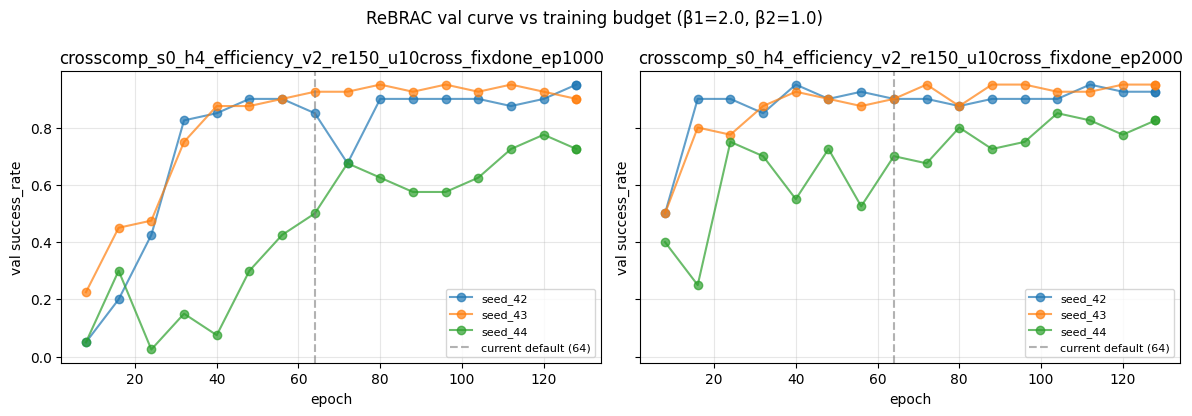

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, dataset_name in zip(axes, DATASETS):
    for seed in SEEDS:
        cands = load_candidates(dataset_name, seed)
        if not cands:
            continue
        epochs = to_epoch(cands, TRAIN_EPOCHS)
        succ   = [c["eval_success_rate"] for c in cands]
        ax.plot(epochs, succ, marker="o", alpha=0.7, label=f"seed_{seed}")
    ax.axvline(REFERENCE_EPOCH, linestyle="--", color="gray", alpha=0.6, label=f"current default ({REFERENCE_EPOCH})")
    ax.set_title(dataset_name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("val success_rate")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("ReBRAC val curve vs training budget (β1=2.0, β2=1.0)")
fig.tight_layout()
plt.show()


In [11]:
# Peak epoch 汇总表：每 (dataset, seed) 的 val success_rate 峰值出现在哪一个 epoch。
print(f"{'dataset':<18}{'seed':<8}{'peak_epoch':<12}{'peak_success':<14}{'succ@ep64':<12}{'Δ (peak - ep64)':<18}")
print("-" * 84)
for dataset_name in DATASETS:
    for seed in SEEDS:
        cands = load_candidates(dataset_name, seed)
        if not cands:
            continue
        epochs = to_epoch(cands, TRAIN_EPOCHS)
        succ   = [c["eval_success_rate"] for c in cands]
        peak_idx  = max(range(len(succ)), key=lambda i: succ[i])
        peak_ep   = epochs[peak_idx]
        peak_succ = succ[peak_idx]
        # 与 epoch=64 最近的那个 ckpt
        ref_idx   = min(range(len(epochs)), key=lambda i: abs(epochs[i] - REFERENCE_EPOCH))
        ref_succ  = succ[ref_idx]
        delta     = peak_succ - ref_succ
        print(f"{dataset_name:<18}{seed:<8}{peak_ep:<12.1f}{peak_succ:<14.4f}{ref_succ:<12.4f}{delta:<+18.4f}")


dataset           seed    peak_epoch  peak_success  succ@ep64   Δ (peak - ep64)   
------------------------------------------------------------------------------------
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep100042      128.0       0.9500        0.8500      +0.1000           
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep100043      80.0        0.9500        0.9250      +0.0250           
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep100044      120.0       0.7750        0.5000      +0.2750           
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep200042      40.0        0.9500        0.9000      +0.0500           
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep200043      72.0        0.9500        0.9000      +0.0500           
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep200044      104.0       0.8500        0.7000      +0.1500           


## 5. 决策规则

看上图 + 表：

| 观察 | 结论 | 下一步 |
|---|---|---|
| 两 dataset 的 peak 都在 epoch ≤ 50，之后平稳或轻微下滑 | `TRAIN_EPOCHS=64` 充足甚至偏多 | 正式 screening 维持 64，或降到 48 节省预算 |
| `1000` 的 peak ≈ 40，`2000` 的 peak ≥ 80 且仍在上升 | 2000 确实需要更大预算 | 对 2000 单独用 `TRAIN_EPOCHS=96` 或 `128` 再跑一次正式 screening |
| 两 dataset 的 peak 都在 epoch ≥ 80 | 64 系统性不够 | 正式 screening 统一上调到 96 或 128 |
| 两 dataset 的 peak 都很早（≤ 24），之后明显回落 | 过拟合信号 | 保留 64，但额外调查 β1/β2 是否也需要收紧 |

**`Δ (peak - ep64)`** 列的意义：如果这一列的绝对值在所有 seed 上都很小（比如 < 0.02），那 64 epoch 的效率/效果比就是最佳折衷；如果系统性为正且 > 0.05，说明继续训练能稳定拿到改善。


## 6. Sanity check（可选）：长训 ckpt ≈ 单独训 64 epoch?

如果你之前在**正式 screening 目录**里也跑过 `(β1=2.0, β2=1.0, seed=42, crosscomp-1000)` 并且 `TRAIN_EPOCHS=64`，
可以比较那个 `agent_final.pt` 和本次长训中「epoch≈64」位置的 `agent_step_*.pt` 的权重张量范数，
确认「长训至 step N ≈ 单独训到 N 结束」这个等价性假设成立。

如果没有这样的对照 run，整段会自动 skip。


In [12]:
import torch

PROBE_CKPT_ROOT = Path(os.environ["CHECKPOINT_ROOT"]) / "crosscomp-1000" / PAIR_TAG / "seed_42"
REFERENCE_CKPT_DIR = Path("checkpoints/offline/rebrac/screening/crosscomp-1000") / PAIR_TAG / "seed_42"


def state_dict_l2_distance(path_a: Path, path_b: Path) -> float:
    sd_a = torch.load(path_a, map_location="cpu", weights_only=True)
    sd_b = torch.load(path_b, map_location="cpu", weights_only=True)
    # 训练脚本可能把 state_dict 嵌套在子键里；按需展开。
    if isinstance(sd_a, dict) and "state_dict" in sd_a:
        sd_a = sd_a["state_dict"]
    if isinstance(sd_b, dict) and "state_dict" in sd_b:
        sd_b = sd_b["state_dict"]
    shared = set(sd_a) & set(sd_b)
    sq = 0.0
    numel = 0
    for key in shared:
        ta, tb = sd_a[key], sd_b[key]
        if not torch.is_tensor(ta) or not torch.is_tensor(tb) or ta.shape != tb.shape:
            continue
        diff = (ta.float() - tb.float()).flatten()
        sq += diff.pow(2).sum().item()
        numel += diff.numel()
    return (sq / max(1, numel)) ** 0.5


reference_path = REFERENCE_CKPT_DIR / "agent_final.pt"
if not reference_path.exists():
    print(f"[skip] no matching TRAIN_EPOCHS=64 run under {REFERENCE_CKPT_DIR}")
else:
    # 找本次长训里离 epoch=64 最近的 ckpt。
    probe_cands = load_candidates("crosscomp-1000", "42")
    epochs = to_epoch(probe_cands, TRAIN_EPOCHS)
    ref_idx = min(range(len(epochs)), key=lambda i: abs(epochs[i] - 64))
    probe_agent_file = probe_cands[ref_idx]["agent_file"]
    probe_path = PROBE_CKPT_ROOT / probe_agent_file
    print(f"reference (64-epoch run): {reference_path}")
    print(f"probe    (long run @ ep={epochs[ref_idx]:.1f}): {probe_path}")
    if probe_path.exists():
        rmse = state_dict_l2_distance(reference_path, probe_path)
        print(f"per-parameter RMSE: {rmse:.6f}")
        print("解读：如果这个 RMSE 明显小于权重本身的典型尺度（通常 ~0.01 数量级已经算很小了），"
              "说明两种训练路径在 epoch=64 位置产出的权重近似一致，等价性假设成立。")
    else:
        print(f"[skip] probe ckpt missing: {probe_path}")


[skip] no matching TRAIN_EPOCHS=64 run under checkpoints/offline/rebrac/screening/crosscomp-1000/actorb_2p0__criticb_1p0/seed_42
